# IMPORT LIBRARIES & LOAD DATA
---
*Setting the environment and reading the datasets*

In [1]:
## IMPORT LIBRARIES AND LOAD DATA
import pandas as pd
import numpy as np

# Load the dataset
file_path = 'video-games-2022.csv'
df = pd.read_csv(file_path)

# Display the first few rows and data info
print("Initial Data Snapshot:")
display(df.head())
print("\nData Information:")
df.info()

Initial Data Snapshot:


,Month,Day,Title,Platform(s),Genre(s),Developer(s),Publisher(s)
0,JANUARY,3,Freddi Fish 3: The Case of the Stolen Conch Shell,NS,Adventure,Humongous Entertainment,UFO Interactive Games
1,JANUARY,3,Putt-Putt Travels Through Time,NS,Adventure,Humongous Entertainment,UFO Interactive Games
2,JANUARY,4,Deep Rock Galactic,"PS4, PS5",First-person shooter,Ghost Ship Games,Coffee Stain Publishing
3,JANUARY,4,The Pedestrian,"XBO, XSX","Puzzle, platform",Skookum Arts LLC,Skookum Arts LLC
4,JANUARY,6,Demon Gaze Extra,"NS, PS4",Role-playing,Cattle Call,Clouded Leopard Entertainment



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Month         987 non-null    object
 1   Day           987 non-null    int64 
 2   Title         987 non-null    object
 3   Platform(s)   987 non-null    object
 4   Genre(s)      987 non-null    object
 5   Developer(s)  987 non-null    object
 6   Publisher(s)  987 non-null    object
dtypes: int64(1), object(6)
memory usage: 54.1+ KB


---
# DATA CLEANING
---
*Handling missing values, duplactions, and standardising formatting*

In [2]:
## DATA CLEANING
# Standardize column names (lowercase, underscores, AND remove parentheses)
df.columns = (df.columns
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('(', '', regex=False)
              .str.replace(')', '', regex=False))

print("Cleaned Columns:", df.columns.tolist())

# Check for missing values
missing_data = df.isnull().sum()
print("\nMissing values per column:\n", missing_data)

# Handle Duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"\nRemoved {duplicates} duplicate rows.")
else:
    print("\nNo duplicate rows found.")

# Clean up text casing
df['month'] = df['month'].str.title()

display(df.head())

Cleaned Columns: ['month', 'day', 'title', 'platforms', 'genres', 'developers', 'publishers']

Missing values per column:
 month         0
day           0
title         0
platforms     0
genres        0
developers    0
publishers    0
dtype: int64

No duplicate rows found.


,month,day,title,platforms,genres,developers,publishers
0,January,3,Freddi Fish 3: The Case of the Stolen Conch Shell,NS,Adventure,Humongous Entertainment,UFO Interactive Games
1,January,3,Putt-Putt Travels Through Time,NS,Adventure,Humongous Entertainment,UFO Interactive Games
2,January,4,Deep Rock Galactic,"PS4, PS5",First-person shooter,Ghost Ship Games,Coffee Stain Publishing
3,January,4,The Pedestrian,"XBO, XSX","Puzzle, platform",Skookum Arts LLC,Skookum Arts LLC
4,January,6,Demon Gaze Extra,"NS, PS4",Role-playing,Cattle Call,Clouded Leopard Entertainment


---
# DATA VALIDATION
---
*Ensuring data quality and logic*

In [3]:
##  DATA VALIDATION: DATE & INTEGRITY CHECKS ---

# Define valid months and their maximum days for 2022
month_days = {
    'JANUARY': 31, 'FEBRUARY': 28, 'MARCH': 31, 'APRIL': 30,
    'MAY': 31, 'JUNE': 30, 'JULY': 31, 'AUGUST': 31,
    'SEPTEMBER': 30, 'OCTOBER': 31, 'NOVEMBER': 30, 'DECEMBER': 31
}

# Check for invalid Months
invalid_months = df[~df['month'].str.upper().isin(month_days.keys())]
if not invalid_months.empty:
    print(f"Warning: Found {len(invalid_months)} rows with invalid month names.")
else:
    print("Check Passed: All month names are valid.")

# Check for invalid Days (e.g., Day 32 or February 30th)
def is_valid_day(row):
    month = row['month'].upper()
    day = row['day']
    if month in month_days:
        return 1 <= day <= month_days[month]
    return False

invalid_days = df[~df.apply(is_valid_day, axis=1)]
if not invalid_days.empty:
    print(f"Warning: Found {len(invalid_days)} rows with impossible dates (e.g., Feb 30).")
    # Clip days to the maximum allowed for that month
    df['day'] = df.apply(lambda x: min(x['day'], month_days.get(x['month'].upper(), 31)), axis=1)
else:
    print("Check Passed: All release dates are calendar-valid.")

# Check for missing critical data (Empty Titles)
missing_titles = df['title'].isnull().sum()
if missing_titles > 0:
    print(f"Warning: Found {missing_titles} games missing a Title. Removing these rows...")
    df = df.dropna(subset=['title'])

Check Passed: All month names are valid.
Check Passed: All release dates are calendar-valid.


---
# DATA TRANSFORMATION & FEATURE ENGINEERING
---
*Creating new data variables for analysis*

In [4]:
## DATA TRANSFORMATION & FEATURE ENGINEERING

# This use the cleaned column names | Ensures columns exists even if previous cells were skipped
df['platform_count'] = df['platforms'].str.split(',').str.len().fillna(0)
df['genre_count'] = df['genres'].str.split(',').str.len().fillna(0)
df['developer_count'] = df['developers'].str.split(',').str.len().fillna(0)
df['total_tags'] = df['platform_count'] + df['genre_count'] + df['developer_count']

# Create a feature: Platform Density (How much of the game's metadata is platform-related)
df['platform_ratio'] = (df['platform_count'] / df['total_tags']).round(4)

# Categorize 'total_tags' into bins (Metadata Volume)
df['metadata_volume'] = pd.qcut(df['total_tags'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

# One-hot encoding for the 'month' column (useful for seasonality analysis)
df_final = pd.get_dummies(df, columns=['month'], prefix='month')

print("Transformation complete. New columns added.")
print(f"New features: 'platform_ratio', 'metadata_volume', and {len([c for c in df_final.columns if 'month_' in c])} month-dummy columns.")

# Display the final prepared dataframe
display(df_final.head())

Transformation complete. New columns added.
New features: 'platform_ratio', 'metadata_volume', and 12 month-dummy columns.


,day,title,platforms,genres,developers,publishers,platform_count,genre_count,developer_count,total_tags,...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,3,Freddi Fish 3: The Case of the Stolen Conch Shell,NS,Adventure,Humongous Entertainment,UFO Interactive Games,1,1,1,3,...,False,False,True,False,False,False,False,False,False,False
1,3,Putt-Putt Travels Through Time,NS,Adventure,Humongous Entertainment,UFO Interactive Games,1,1,1,3,...,False,False,True,False,False,False,False,False,False,False
2,4,Deep Rock Galactic,"PS4, PS5",First-person shooter,Ghost Ship Games,Coffee Stain Publishing,2,1,1,4,...,False,False,True,False,False,False,False,False,False,False
3,4,The Pedestrian,"XBO, XSX","Puzzle, platform",Skookum Arts LLC,Skookum Arts LLC,2,2,1,5,...,False,False,True,False,False,False,False,False,False,False
4,6,Demon Gaze Extra,"NS, PS4",Role-playing,Cattle Call,Clouded Leopard Entertainment,2,1,1,4,...,False,False,True,False,False,False,False,False,False,False


---
# SECTION 1 :- DATA VISUALIZATIONS
---
> **To identify trends and correlations across gloabl university research projects.** 

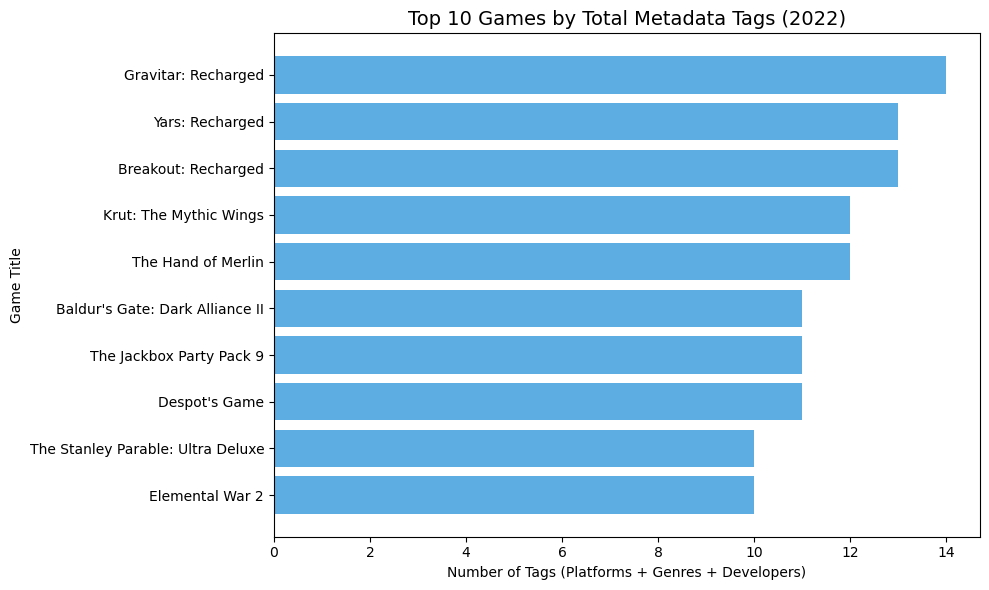

In [5]:
## 1. BAR CHART: COMPARATIVE PERFORMANCE
## The chart shows which video games lead in total metadata tags (Platforms + Genres + Developers)

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the figure size is appropriate
plt.figure(figsize=(10, 6))

# Get the top 10 games by total_tags and sort for the horizontal bar chart
top_10_games = df.nlargest(10, 'total_tags').sort_values('total_tags', ascending=True)

# Create the horizontal bar chart
plt.barh(top_10_games['title'], top_10_games['total_tags'], color='#5DADE2')

# Update Titles and Labels
plt.title('Top 10 Games by Total Metadata Tags (2022)', fontsize=14)
plt.xlabel('Number of Tags (Platforms + Genres + Developers)')
plt.ylabel('Game Title')

# Adjust layout to prevent text clipping
plt.tight_layout()
plt.show()

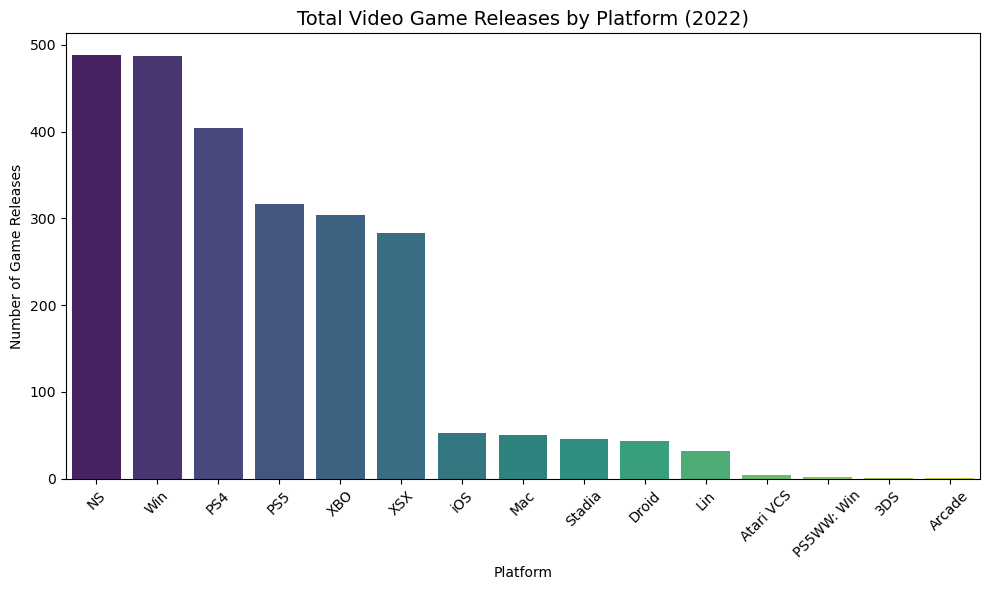

In [6]:
## 2. PLATFORM DISTRIBUTION : RELEASES BY PLATFORM
## Categorical bar chart to compare the total game releases across different platforms

# Prepare data by splitting comma-separated platforms and "exploding" them
# This ensures a game on "PS4, PS5" counts for both PS4 and PS5
platform_data = df.assign(platforms=df['platforms'].str.split(', ')).explode('platforms')

# Group by platform and count the number of titles
platform_counts = platform_data.groupby('platforms')['title'].count().sort_values(ascending=False).reset_index()

# Plotting
plt.figure(figsize=(10, 6))

sns.barplot(
    data=platform_counts.head(15), # Showing top 15 platforms for readability
    x='platforms', 
    y='title', 
    hue='platforms', 
    palette='viridis', 
    legend=False
)

plt.title('Total Video Game Releases by Platform (2022)', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Platform')
plt.ylabel('Number of Game Releases')
plt.tight_layout()
plt.show()

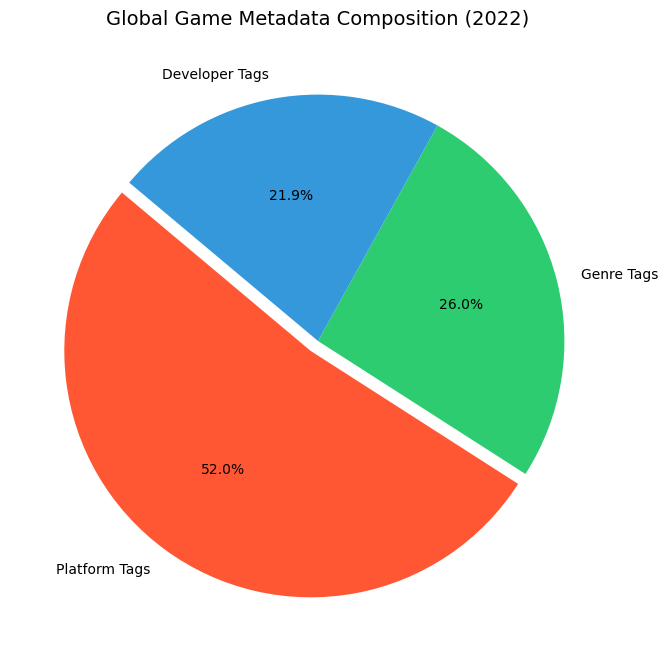

In [7]:
## 3. COMPOSITION ANALYSIS : METADATA BREAKDOWN
## Pie chart to visualize the global share of Platforms, Genres, and Developers

# Summing up the counts we created in the validation step
totals = df[['platform_count', 'genre_count', 'developer_count']].sum()

plt.figure(figsize=(8, 8))

# Create the pie chart using the new labels
plt.pie(totals, 
        labels=['Platform Tags', 'Genre Tags', 'Developer Tags'], 
        autopct='%1.1f%%', 
        colors=['#FF5733', '#2ECC71', '#3498DB'], 
        startangle=140, 
        explode=(0.05, 0, 0)) # Slightly pulling out the first slice for emphasis

plt.title('Global Game Metadata Composition (2022)', fontsize=14)
plt.show()

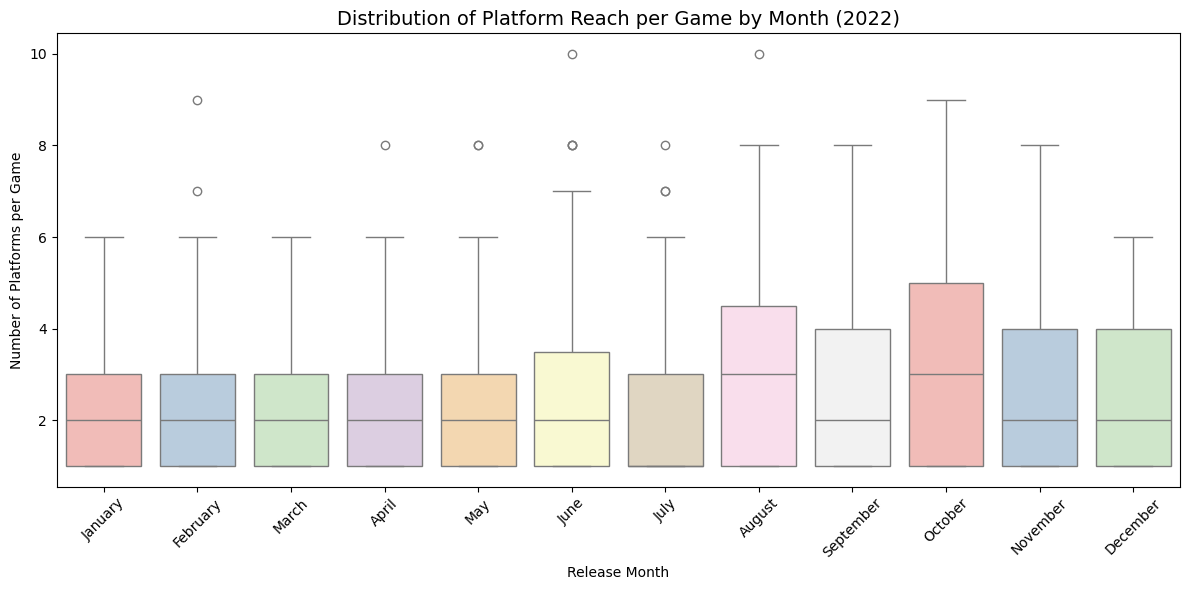

In [8]:
## 4. DISTRIBUTION ANALYSIS : PLATFORM REACH BY MONTH
## Box plot to see the spread and outliers of multi-platform releases across different months

# Ensure months are in chronological order for the x-axis
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))

# Mapping: 
# 'faculty' -> 'month'
# 'ai_projects' -> 'platform_count'
sns.boxplot(
    data=df, 
    x='month', 
    y='platform_count', 
    hue='month', 
    palette='Pastel1', 
    order=month_order,
    legend=False
)

plt.title('Distribution of Platform Reach per Game by Month (2022)', fontsize=14)
plt.ylabel('Number of Platforms per Game')
plt.xlabel('Release Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

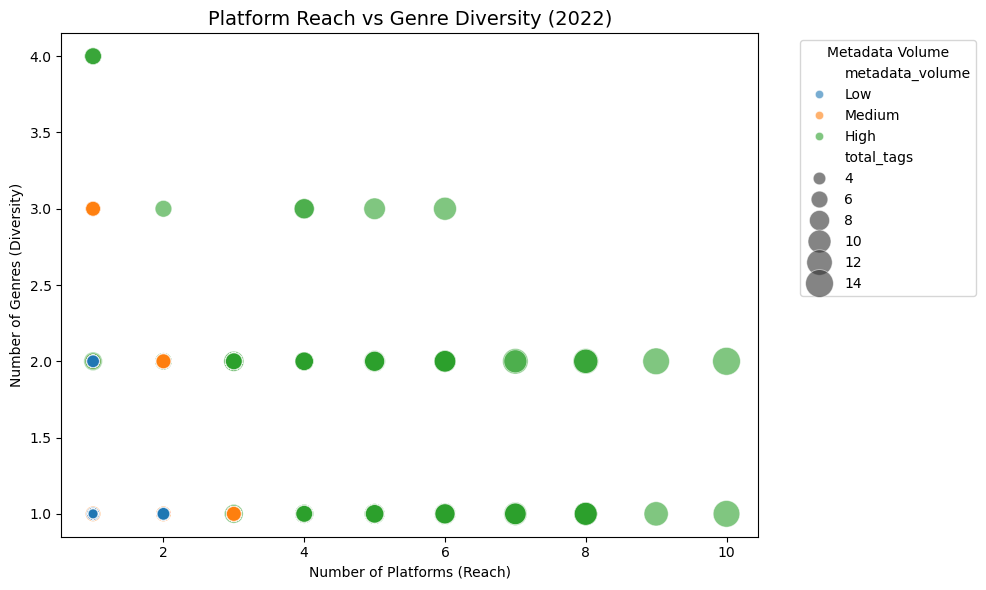

In [9]:
## 5. RELATIONSHIP ANALYSIS : PLATFORMS VS GENRES
## Scatter plot to observe if there is a correlation between Platform Reach and Genre Diversity

# Recalculate metadata_volume to ensure the column exists for the plot
# duplicates='drop' is used because many games have the same number of tags
df['metadata_volume'] = pd.qcut(df['total_tags'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

plt.figure(figsize=(10, 6))

# Mapping
sns.scatterplot(
    data=df, 
    x='platform_count', 
    y='genre_count', 
    hue='metadata_volume', 
    size='total_tags', 
    sizes=(50, 400), # Increased size range for better visibility
    alpha=0.6
)

plt.title('Platform Reach vs Genre Diversity (2022)', fontsize=14)
plt.xlabel('Number of Platforms (Reach)')
plt.ylabel('Number of Genres (Diversity)')

# Moving the legend outside to prevent overlap with data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Metadata Volume')

plt.tight_layout()
plt.show()

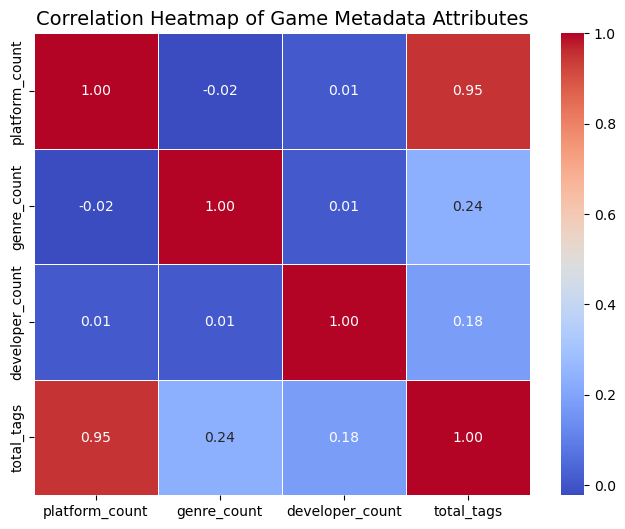

In [10]:
## 6. HEATMAP : CORRELATION MATRIX

plt.figure(figsize=(8, 6))

# Mapping
numeric_cols = ['platform_count', 'genre_count', 'developer_count', 'total_tags']
correlation = df[numeric_cols].corr()

# Create the heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Game Metadata Attributes', fontsize=14)
plt.show()

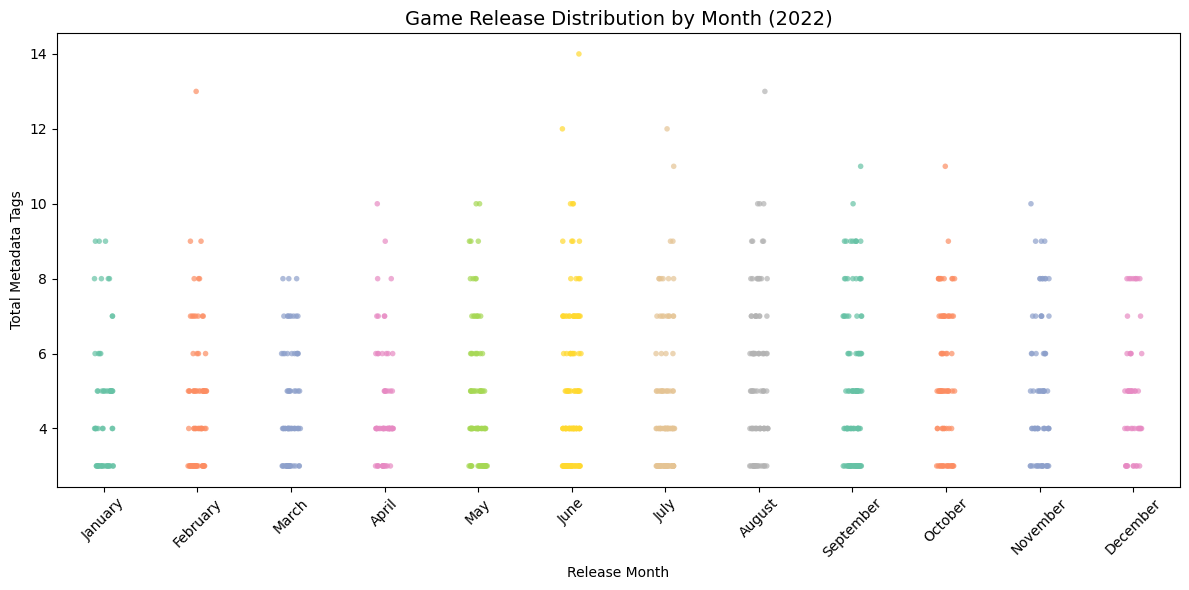

In [11]:
## 7. SWARM PLOT : RELEASE INTENSITY BY MONTH
## Swarm plot helps to see the density of game releases and their metadata complexity across months

# Ensure months are in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))

# Mapping remains exactly the same
sns.stripplot(
    data=df, 
    x='month', 
    y='total_tags', 
    hue='month', 
    palette='Set2', 
    order=month_order,
    size=4, 
    jitter=True,
    alpha=0.7,     
    legend=False
)

plt.title('Game Release Distribution by Month (2022)', fontsize=14)
plt.ylabel('Total Metadata Tags')
plt.xlabel('Release Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

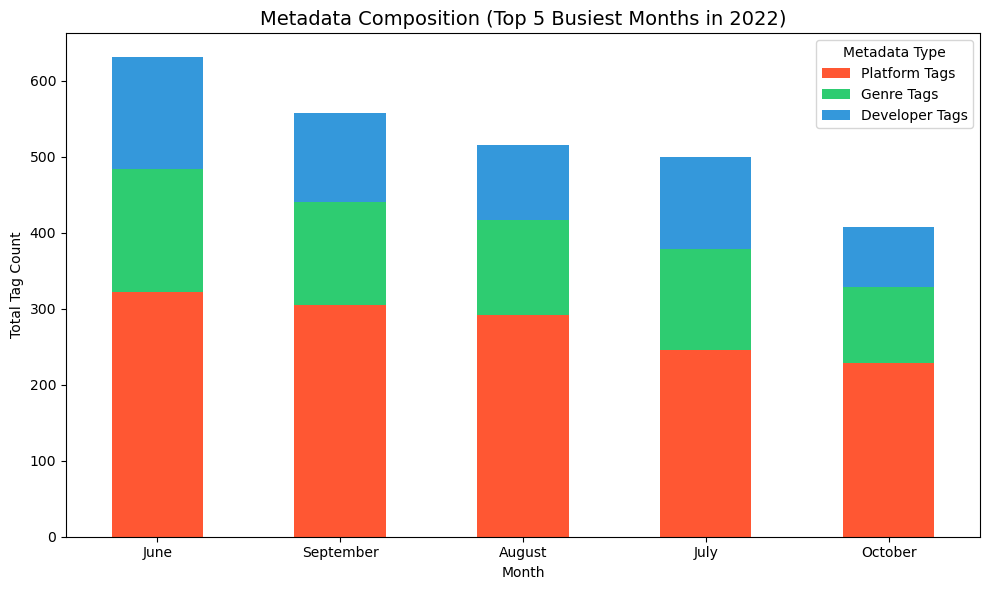

In [12]:
## 8. STACKED BAR CHART : METADATA COMPOSITION BY MONTH 
## Shows the metadata breakdown for the top 5 busiest release months

# Mapping
month_stacks = df.groupby('month')[['platform_count', 'genre_count', 'developer_count']].sum()

#Take top 5 months based on the total volume of tags
top_5_months = month_stacks.sum(axis=1).nlargest(5).index
month_stacks = month_stacks.loc[top_5_months]

# Plotting
month_stacks.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#FF5733', '#2ECC71', '#3498DB'])

plt.title('Metadata Composition (Top 5 Busiest Months in 2022)', fontsize=14)
plt.ylabel('Total Tag Count')
plt.xlabel('Month')
plt.xticks(rotation=0) 
plt.legend(title='Metadata Type', labels=['Platform Tags', 'Genre Tags', 'Developer Tags'])

plt.tight_layout()
plt.show()

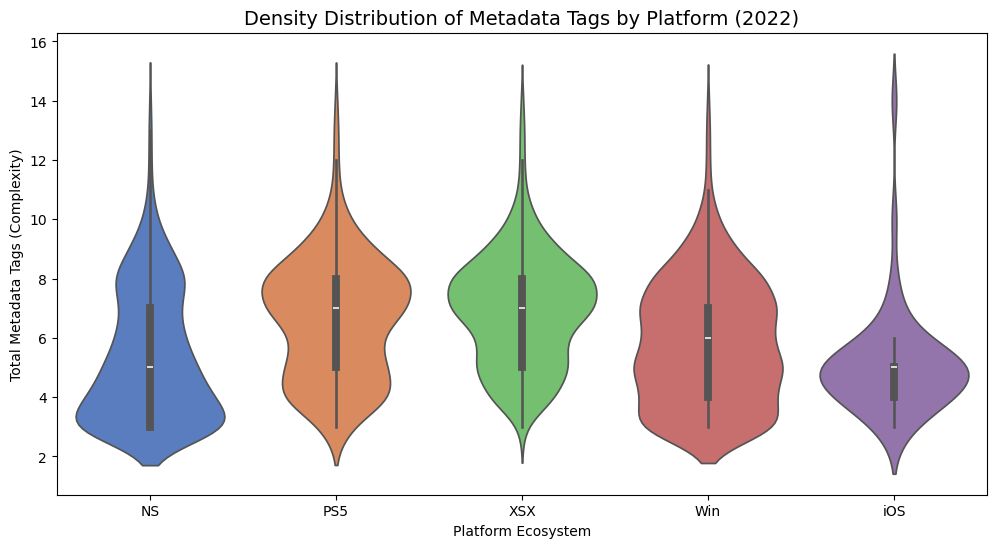

In [13]:
## 9. VIOLIN PLOT : DISTRIBUTION OF METADATA COMPLEXITY BY PLATFORM
## Combining a box plot and density plot to see the "shape" of game complexity across platforms

# Prepare data: Explode the platforms so each platform gets its own row
# This ensures a game on "Win, PS5" is counted in both categories
df_exploded = df.assign(platforms=df['platforms'].str.split(', ')).explode('platforms')

# Filter for specific target platforms to keep the chart clean
# Mapping: target_countries -> target_platforms
# 'Win' = PC, 'NS' = Nintendo Switch, 'PS5' = PlayStation 5, 'XSX' = Xbox Series X
target_platforms = ['Win', 'NS', 'PS5', 'XSX', 'iOS']
filtered_platforms = df_exploded[df_exploded['platforms'].isin(target_platforms)]

plt.figure(figsize=(12, 6))

# Mapping:
sns.violinplot(
    data=filtered_platforms, 
    x='platforms', 
    y='total_tags', 
    hue='platforms', 
    palette='muted', 
    legend=False
)

plt.title('Density Distribution of Metadata Tags by Platform (2022)', fontsize=14)
plt.ylabel('Total Metadata Tags (Complexity)')
plt.xlabel('Platform Ecosystem')
plt.show()

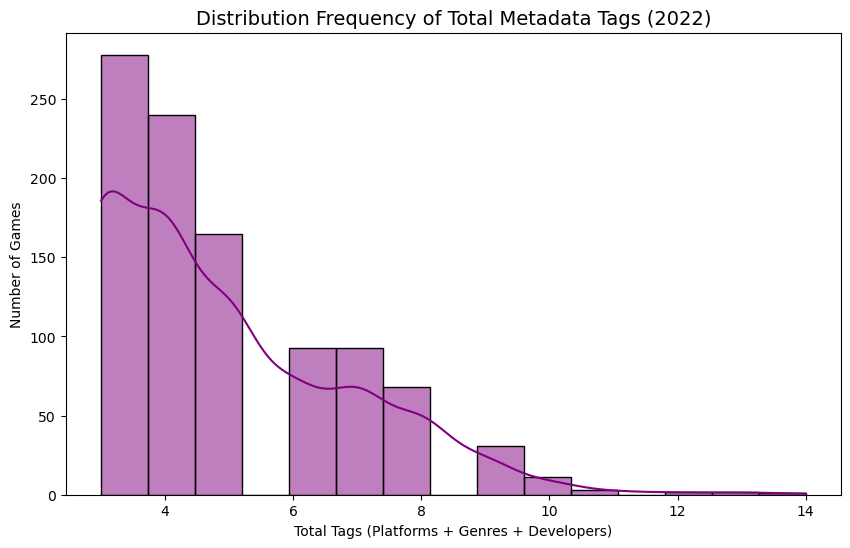

In [14]:
## 10. HISTOGRAM WITH KDE : OVERALL METADATA DENSITY
## Shows the frequency distribution of total tags across all games
## With Kernel Density Estimate (KDE) line to show the smooth shape of the data

plt.figure(figsize=(10, 6))

# Mapping
sns.histplot(df['total_tags'], kde=True, color='purple', bins=15)

plt.title('Distribution Frequency of Total Metadata Tags (2022)', fontsize=14)
plt.xlabel('Total Tags (Platforms + Genres + Developers)')
plt.ylabel('Number of Games')

plt.show()

---
# SECTION 2 : FUNCTIONAL AND RELVEANT FILTERS

In [15]:
%%writefile streamlitapp.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD & CLEAN DATA
df = pd.read_csv('video-games-2022.csv')

# Standardize column names (lowercase and no parentheses)
df.columns = (df.columns
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('(', '', regex=False)
              .str.replace(')', '', regex=False))

# FEATURE ENGINEERING
df['platform_count'] = df['platforms'].str.split(',').str.len().fillna(0)
df['genre_count'] = df['genres'].str.split(',').str.len().fillna(0)
df['developer_count'] = df['developers'].str.split(',').str.len().fillna(0)
df['total_tags'] = df['platform_count'] + df['genre_count'] + df['developer_count']

# MappingPlatform Ratio
df['platform_ratio'] = (df['platform_count'] / df['total_tags']).round(4)

# MappingMetadata Volume
df['metadata_volume'] = pd.qcut(df['total_tags'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

df['month'] = df['month'].str.title()

st.set_page_config(page_title="2022 Video Game Analytics", layout="wide")
st.title("🎮 2022 Video Game Data Analytics")
st.header("Section 2: Functional & Relevant Game Filters")

# --- SIDEBAR: 10 RELEVANT FILTERS ---
st.sidebar.header("Filter Dashboard")

# Filter 1: Text Search
search_title = st.sidebar.text_input("1. Search Game Title", "")

# Filter 2: Platforms (Handling multiple platforms per game)
all_plats = sorted(list(set([p.strip() for sublist in df['platforms'].str.split(',').tolist() for p in sublist])))
sel_plats = st.sidebar.multiselect("2. Select Platforms", all_plats, default=all_plats)

# Filter 3: Months
months = st.sidebar.multiselect("3. Select Release Month", df['month'].unique(), default=df['month'].unique())

# Filter 4 & 5: Numerical Ranges
t_min, t_max = int(df['total_tags'].min()), int(df['total_tags'].max())
tag_range = st.sidebar.slider("4. Total Tags Range", t_min, t_max, (t_min, t_max))
day_range = st.sidebar.slider("5. Day of Month Range", 1, 31, (1, 31))

# Filter 6, 7, & 8: Specific Min counts
min_p = st.sidebar.number_input("6. Min Platform Count", 0, value=0)
min_g = st.sidebar.number_input("7. Min Genre Count", 0, value=0)
min_d = st.sidebar.number_input("8. Min Developer Count", 0, value=0)

# Filter 9: Calculated Threshold
min_ratio = st.sidebar.slider("9. Min Platform Focus (%)", 0, 100, 0) / 100

# Filter 10: Volume Category
vol_choice = st.sidebar.radio("10. Metadata Volume Category", ["All", "Low", "Medium", "High"])

# --- APPLYING FILTER LOGIC ---
# Custom filter for the comma-separated platforms string
def plat_check(plat_str, selected):
    game_plats = [p.strip() for p in plat_str.split(',')]
    return any(p in selected for p in game_plats)

mask = (
    df['title'].str.contains(search_title, case=False, na=False) &
    df['month'].isin(months) &
    df['total_tags'].between(tag_range[0], tag_range[1]) &
    df['day'].between(day_range[0], day_range[1]) &
    (df['platform_count'] >= min_p) &
    (df['genre_count'] >= min_g) &
    (df['developer_count'] >= min_d) &
    (df['platform_ratio'] >= min_ratio)
)

filtered_df = df[mask]
filtered_df = filtered_df[filtered_df['platforms'].apply(lambda x: plat_check(x, sel_plats))]

if vol_choice != "All":
    filtered_df = filtered_df[filtered_df['metadata_volume'] == vol_choice]

# --- DISPLAY DATA ---
st.write(f"### Games Found: {len(filtered_df)}")
st.dataframe(filtered_df, use_container_width=True)

# --- DISPLAY VISUALS ---
if not filtered_df.empty:
    st.subheader("Visual Analysis of Filtered Data")
    fig, ax = plt.subplots(figsize=(10, 5))
    # Bar chart showing the Top 10 filtered games by their metadata richness
    sns.barplot(data=filtered_df.head(10), x='total_tags', y='title', hue='month', ax=ax)
    plt.title("Filtered Performance: Top 10 Games by Metadata Volume")
    st.pyplot(fig) 
else:
    st.warning("No games found matching these criteria.")

Overwriting streamlitapp.py


In [16]:
!streamlit run streamlitapp.py

^C
